# Notebook 1 — Data Preprocessing & LSTM Surrogate Model
## Neural MPC for Iron Ore Flotation Plant
### Advanced Machine Learning — Unit 7: Control Engineering

---

## Project Overview

This notebook covers the first half of a **Neural MPC** project applied to an iron ore
flotation plant. The goal is to train a neural network that learns the plant's behaviour
from historical data, so it can later be used inside a Model Predictive Control (MPC) loop.

**Why do we need a neural network here?**
The flotation plant is a complex industrial process with 14 controllable inputs (air flows
and liquid levels across 7 columns) and 2 key outputs (iron and silica concentrations).
The physics governing this process — bubble dynamics, surface chemistry, fluid coupling —
are too complex to model with equations. Instead, we learn the input-output behaviour
directly from data.

This approach is called **Learning-based MPC** and is discussed in Unit 7 (slide 28):
> *"Use NN to learn the unknown physics. E.g.: uses formulas for general drone flight,
> but NN for modelling ground-effects."*

**What this notebook does, step by step:**
1. Load and clean the dataset
2. Define the three variable types (MV, DV, CV) from control theory
3. Engineer basic features (lag differences + rolling means)
4. Build and train an LSTM network to predict plant outputs
5. Evaluate the model and compare it against a naive baseline
6. Save all artifacts for Notebook 2

---

## Variable Classification (Unit 7, Slide 8)

| Type | Name | Columns | Role |
|------|------|---------|------|
| **MV** — Manipulated Variables | Control actions (u) | 7 Air Flows + 7 Levels | The MPC controller decides these |
| **DV** — Disturbance Variables | Measured disturbances (d) | 5 Feed properties | Observable but uncontrollable |
| **CV** — Controlled Variables | Outputs (y) | % Iron + % Silica | What we want to control |


---
## Step 1 — Imports

We import the standard libraries needed for data handling, visualisation, and deep learning.
`torch` is used for the LSTM model, `sklearn` for scaling, and `pickle` to save objects
that Notebook 2 will load.


In [1]:
import zipfile
import pickle
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print(f"PyTorch version : {torch.__version__}")
print(f"Running on      : {DEVICE}")


PyTorch version : 2.12.0+cu130
Running on      : cuda


The `DEVICE` variable automatically selects GPU if available, otherwise falls back to CPU.
All model tensors will be sent to this device during training.


---
## Step 2 — Load the Dataset

The data comes as a ZIP archive containing a single CSV file. We extract it, load it,
and perform basic cleaning: parsing the date column, sorting chronologically, and
removing duplicate timestamps (the raw file has many repeated rows at second-level
resolution — we keep only one measurement per hour).


In [4]:
CSV_PATH = 'MiningProcess_Flotation_Plant_Database.csv'

# The file uses comma as the decimal separator (European format)
df_raw = pd.read_csv(CSV_PATH, sep=',', decimal=',')

# Parse date, sort, and remove duplicate timestamps
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = (df_raw
          .sort_values('date')
          .drop_duplicates(subset='date')
          .reset_index(drop=True))

print(f"Shape after cleaning : {df_raw.shape}")
print(f"Date range           : {df_raw['date'].min()}  →  {df_raw['date'].max()}")
print(f"Sampling frequency   : {df_raw['date'].diff().mode()[0]}")


Shape after cleaning : (4097, 24)
Date range           : 2017-03-10 01:00:00  →  2017-09-09 23:00:00
Sampling frequency   : 0 days 01:00:00


After cleaning we have **4,097 hourly observations** spanning about 6 months
of plant operation (March–September 2017). Each row represents one hour of process data.


---
## Step 3 — Define the Three Variable Groups

Following the control engineering taxonomy from Unit 7 (slide 8), we split the 21
relevant columns into their functional roles. Three columns are dropped:
- `date` — only used for sorting, not a feature
- `Starch Flow` and `Amina Flow` — excluded due to data inconsistencies


In [5]:
# --- Manipulated Variables (MV): the 14 actuators the MPC controller will adjust ---
MV_COLS = [
    'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
    'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
    'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
    'Flotation Column 07 Air Flow',
    'Flotation Column 01 Level',    'Flotation Column 02 Level',
    'Flotation Column 03 Level',    'Flotation Column 04 Level',
    'Flotation Column 05 Level',    'Flotation Column 06 Level',
    'Flotation Column 07 Level',
]

# --- Disturbance Variables (DV): feed properties we can measure but not control ---
DV_COLS = [
    'Ore Pulp Flow', '% Iron Feed', '% Silica Feed',
    'Ore Pulp pH', 'Ore Pulp Density',
]

# --- Controlled Variables (CV): the two outputs we want to optimise ---
CV_COLS = ['% Iron Concentrate', '% Silica Concentrate']

ALL_COLS = MV_COLS + DV_COLS + CV_COLS   # 21 columns total
df = df_raw[ALL_COLS].copy()

print(f"Manipulated Variables  (MV): {len(MV_COLS)}")
print(f"Disturbance Variables  (DV): {len(DV_COLS)}")
print(f"Controlled Variables   (CV): {len(CV_COLS)}")
print(f"Total feature columns      : {len(ALL_COLS)}")
print()
df.describe().T[['mean', 'std', 'min', 'max']].round(3)


Manipulated Variables  (MV): 14
Disturbance Variables  (DV): 5
Controlled Variables   (CV): 2
Total feature columns      : 21



,mean,std,min,max
Flotation Column 01 Air Flow,280.182,29.606,175.796,353.204
Flotation Column 02 Air Flow,277.184,30.085,177.785,366.781
Flotation Column 03 Air Flow,281.097,28.562,176.772,345.140
Flotation Column 04 Air Flow,299.449,2.580,293.265,305.859
Flotation Column 05 Air Flow,299.942,3.642,287.029,307.536
Flotation Column 06 Air Flow,292.055,30.333,193.834,370.448
Flotation Column 07 Air Flow,290.934,28.747,186.935,371.097
Flotation Column 01 Level,520.884,132.393,154.991,861.950
Flotation Column 02 Level,522.885,128.174,212.355,828.036
Flotation Column 03 Level,531.050,151.129,130.035,886.605


The CV ranges give us a clear optimisation target:
- **% Iron Concentrate**: between 62% and 68% — we want to **maximise** this
- **% Silica Concentrate**: between 0.6% and 5.5% — we want to **minimise** this

These two objectives are the core of the MPC cost function in Notebook 2.


---
## Step 4 — Exploratory Data Analysis

Before building any model, it is important to understand what the data looks like.
We plot the two output variables over time and check their distributions.


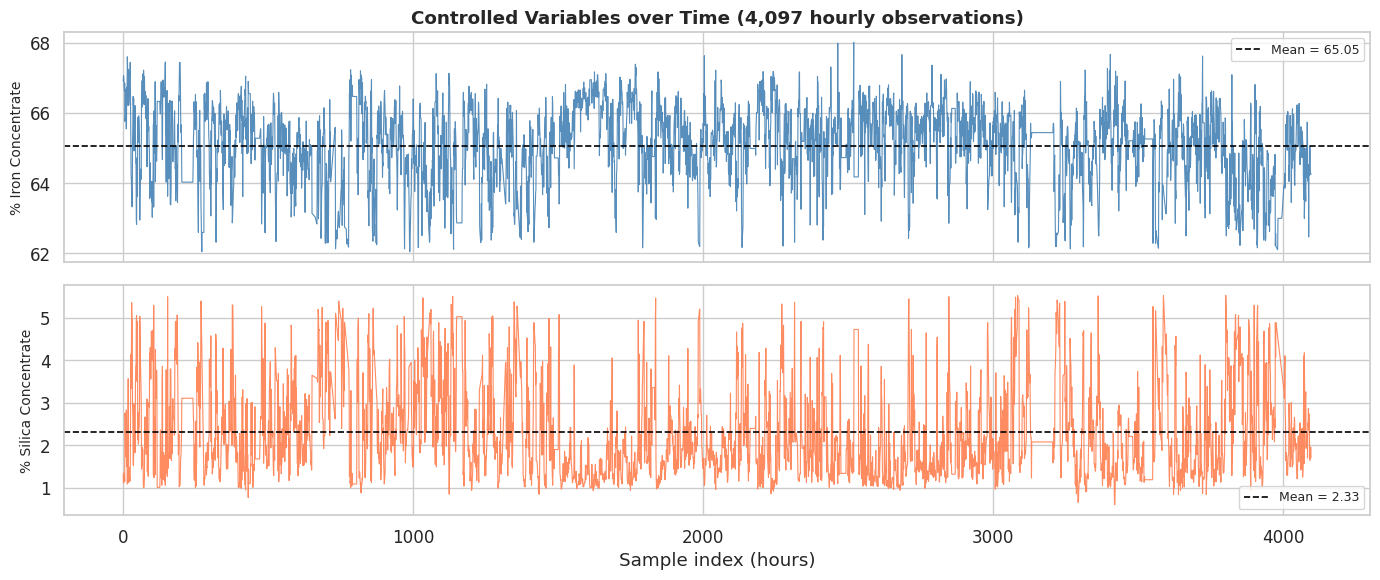

In [6]:
# Time series of the two controlled variables
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, col, color in zip(axes, CV_COLS, ['steelblue', 'coral']):
    ax.plot(df[col].values, color=color, lw=0.8, alpha=0.9)
    ax.axhline(df[col].mean(), color='black', lw=1.2, ls='--',
               label=f'Mean = {df[col].mean():.2f}')
    ax.set_ylabel(col, fontsize=10)
    ax.legend(fontsize=9)

axes[0].set_title('Controlled Variables over Time (4,097 hourly observations)',
                  fontweight='bold')
axes[-1].set_xlabel('Sample index (hours)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'cv_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()


The plots show that both variables fluctuate significantly over time.
Iron concentrate ranges from about 62% to 68%, and silica from 0.6% to 5.5%.
The process is clearly **not stationary** — there are trends, steps, and noisy periods.

This confirms that a static model (e.g., simple linear regression on the current state)
will not be sufficient. We need a **sequence model** that can look back over the last
several hours to capture delayed effects.


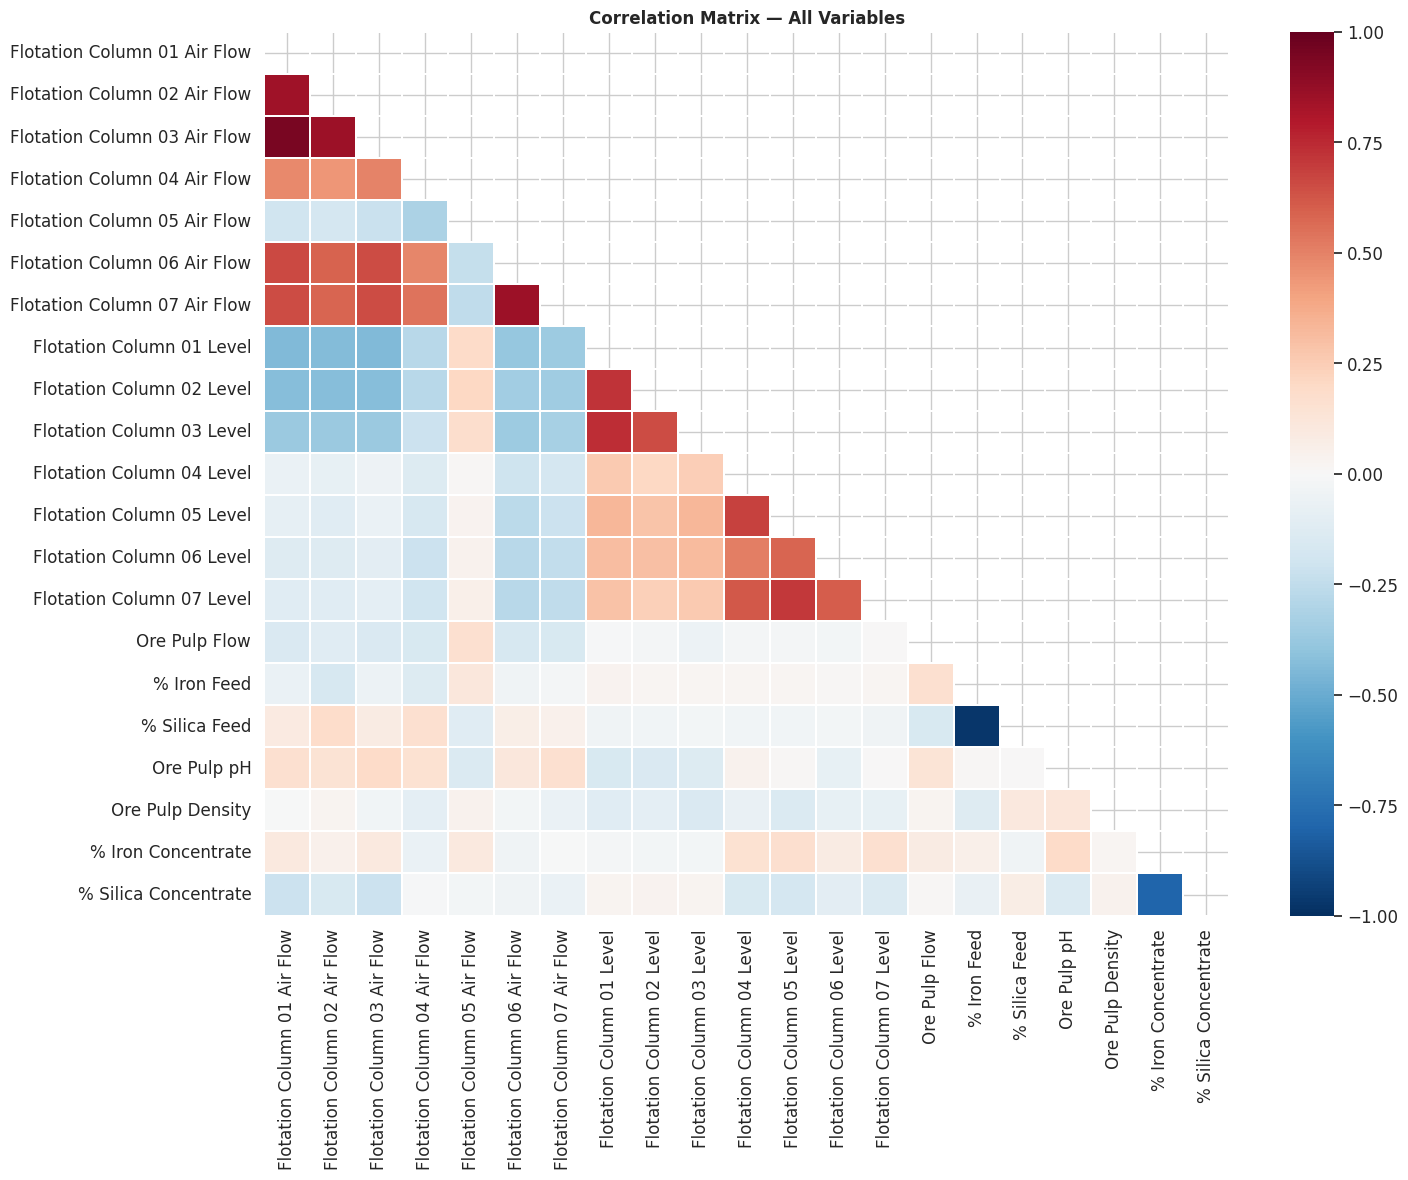

Top correlations with '% Iron Concentrate':


,|correlation|
% Silica Concentrate,0.800
Ore Pulp pH,0.191
Flotation Column 05 Level,0.168
Flotation Column 07 Level,0.160
Flotation Column 04 Level,0.149
Flotation Column 03 Air Flow,0.099
Flotation Column 05 Air Flow,0.098
Flotation Column 01 Air Flow,0.095


In [7]:
# Correlation between inputs and Iron Concentrate
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot=False)
ax.set_title('Correlation Matrix — All Variables', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print top correlations with the primary target
print("Top correlations with '% Iron Concentrate':")
top_corr = (corr['% Iron Concentrate']
            .drop('% Iron Concentrate')
            .abs()
            .sort_values(ascending=False)
            .head(8))
display(top_corr.to_frame('|correlation|').round(3))


The correlation matrix shows which variables have a linear relationship with
the outputs. However, because the flotation process has significant **time delays**
(an actuator change now affects the output 1–6 hours later), raw correlations
underestimate the true predictive power of the inputs. This is why we use a
look-back window and an LSTM — they capture these delayed effects.


---
## Step 5 — Feature Engineering

We add two simple but effective features for each of the 21 base columns:
- **Lag-1 difference**: `x_t - x_{t-1}` — captures how fast each variable is changing
- **6-hour rolling mean**: average of the last 6 observations — captures short-term trends

This gives us **63 features** in total (21 base + 21 differences + 21 rolling means).
No exotic transforms are applied — just straightforward lag and trend features.


In [8]:
def add_features(df_base):
    '''Add lag-1 differences and 6-step rolling means to every column.'''
    result = df_base.copy()
    for col in df_base.columns:
        result[f'{col}_diff1'] = df_base[col].diff(1).fillna(0)
        result[f'{col}_ma6']   = df_base[col].rolling(6, min_periods=1).mean()
    return result

df_features = add_features(df)
FEAT_COLS = df_features.columns.tolist()   # 63 features

print(f"Original features  : {len(ALL_COLS)}")
print(f"After engineering  : {len(FEAT_COLS)}")
print(f"New features added : {len(FEAT_COLS) - len(ALL_COLS)}")
print(f"  - Lag-1 differences for each column")
print(f"  - 6-step rolling means for each column")


Original features  : 21
After engineering  : 63
New features added : 42
  - Lag-1 differences for each column
  - 6-step rolling means for each column


The 63-feature matrix becomes the input to our LSTM. The model will see a window
of the last 24 hours of all 63 features and predict the next hour's output values.


---
## Step 6 — Train/Test Split and Scaling

We split the data **chronologically** (not randomly) to simulate real deployment:
the model trains on the past and is tested on future data it has never seen.

- **70% training**: ~2,867 hours (about 4 months)
- **15% validation**: ~615 hours (used during training to monitor overfitting)
- **15% test**: ~615 hours (used only at the end for final evaluation)

**Important**: the `MinMaxScaler` is fitted **only on the training set** and then
applied to validation and test. Fitting on all data would be a data leakage error —
the model would indirectly "know" the future statistics.


In [9]:
N          = len(df_features)
N_TRAIN    = int(N * 0.70)
N_VAL      = int(N * 0.15)
N_TEST     = N - N_TRAIN - N_VAL

LOOKBACK   = 24   # hours of history the LSTM will see at each step

# Raw numpy arrays
X_all = df_features.values.astype(np.float32)   # (4097, 63)
Y_all = df[CV_COLS].values.astype(np.float32)   # (4097, 2)

# Fit scaler ONLY on training portion
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_all[:N_TRAIN] = scaler_X.fit_transform(X_all[:N_TRAIN])
X_all[N_TRAIN:] = scaler_X.transform(X_all[N_TRAIN:])

Y_all[:N_TRAIN] = scaler_Y.fit_transform(Y_all[:N_TRAIN])
Y_all[N_TRAIN:] = scaler_Y.transform(Y_all[N_TRAIN:])

print(f"Total samples     : {N}")
print(f"Training samples  : {N_TRAIN}")
print(f"Validation samples: {N_VAL}")
print(f"Test samples      : {N_TEST}")
print(f"Look-back window  : {LOOKBACK} hours")
print(f"Input features    : {X_all.shape[1]}")
print(f"Output targets    : {Y_all.shape[1]}")


Total samples     : 4097
Training samples  : 2867
Validation samples: 614
Test samples      : 616
Look-back window  : 24 hours
Input features    : 63
Output targets    : 2


The `LOOKBACK = 24` means we feed 24 consecutive hourly snapshots into the LSTM
at each prediction step. This is a deliberate choice: the flotation process is known
to have transport delays of up to several hours, so 24 hours of history should be
enough to capture the dominant delayed effects.


---
## Step 7 — Building the Sliding Window Dataset

We use a **sliding window** approach: for each time step `t`, we take the last
24 rows of features as input (`X`) and the output at step `t` as the target (`Y`).

```
X[t] = features from hour (t - 24) to hour (t - 1)   shape: (24, 63)
Y[t] = outputs at hour t                               shape: (2,)
```

The windows slide one step at a time, so from 4,097 samples we get ~4,073
(sequence, target) pairs.


In [10]:
class FloatationDataset(Dataset):
    '''Sliding window dataset for the flotation plant.'''

    def __init__(self, X: np.ndarray, Y: np.ndarray, lookback: int):
        self.X        = torch.tensor(X, dtype=torch.float32)
        self.Y        = torch.tensor(Y, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.lookback]   # (lookback, n_features)
        y_tgt = self.Y[idx + self.lookback]          # (2,)
        return x_seq, y_tgt


# Build train / val / test datasets
# We add LOOKBACK to each boundary so each split has its own complete windows
ds_train = FloatationDataset(X_all[:N_TRAIN + LOOKBACK],
                              Y_all[:N_TRAIN + LOOKBACK], LOOKBACK)
ds_val   = FloatationDataset(X_all[N_TRAIN : N_TRAIN + N_VAL + LOOKBACK],
                              Y_all[N_TRAIN : N_TRAIN + N_VAL + LOOKBACK], LOOKBACK)
ds_test  = FloatationDataset(X_all[N_TRAIN + N_VAL:],
                              Y_all[N_TRAIN + N_VAL:], LOOKBACK)

dl_train = DataLoader(ds_train, batch_size=64, shuffle=True,  num_workers=0)
dl_val   = DataLoader(ds_val,   batch_size=64, shuffle=False, num_workers=0)
dl_test  = DataLoader(ds_test,  batch_size=64, shuffle=False, num_workers=0)

print(f"Training sequences  : {len(ds_train)}")
print(f"Validation sequences: {len(ds_val)}")
print(f"Test sequences      : {len(ds_test)}")

# Quick shape check
x_sample, y_sample = ds_train[0]
print(f"\nSample input shape  : {x_sample.shape}   (lookback × features)")
print(f"Sample target shape : {y_sample.shape}   (iron %, silica %)")


Training sequences  : 2867
Validation sequences: 614
Test sequences      : 592

Sample input shape  : torch.Size([24, 63])   (lookback × features)
Sample target shape : torch.Size([2])   (iron %, silica %)


Each sample fed into the LSTM is a matrix of shape (24, 63):
24 time steps, each described by 63 features. The LSTM processes this sequence
left to right, updating its hidden state at each step, and the final hidden state
is used to predict the two output values.


---
## Step 8 — LSTM Model Architecture

We use a straightforward **2-layer stacked LSTM** followed by a small fully-connected
decoder. The design is intentionally simple:

```
Input (24 × 63)
      ↓
  LSTM Layer 1  (hidden size = 128)
      ↓
  LSTM Layer 2  (hidden size = 128)
      ↓
  Last hidden state  (128,)
      ↓
  Dropout (20%)
      ↓
  Linear (128 → 64) + ReLU
      ↓
  Linear (64 → 2)
      ↓
Output (iron %, silica %)
```

**Why LSTM?**
Standard neural networks treat each input independently. An LSTM has **memory** —
its hidden state carries information from previous time steps, making it suitable
for sequences with temporal dependencies like our 24-hour process history.


In [11]:
class LSTMModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout):
        super().__init__()

        # Stacked LSTM: processes the 24-step sequence
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,       # input shape: (batch, seq_len, features)
            dropout     = dropout if num_layers > 1 else 0.0,
        )

        # Decoder: maps the final hidden state to the 2 output values
        self.decoder = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        # x shape: (batch, 24, 63)
        out, _ = self.lstm(x)          # out shape: (batch, 24, hidden_dim)
        last   = out[:, -1, :]         # take only the last time step: (batch, hidden_dim)
        return self.decoder(last)      # (batch, 2)


# Instantiate model
INPUT_DIM  = len(FEAT_COLS)   # 63
HIDDEN_DIM = 128
NUM_LAYERS = 2
OUTPUT_DIM = 2
DROPOUT    = 0.20

model = LSTMModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, OUTPUT_DIM, DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")


LSTMModel(
  (lstm): LSTM(63, 128, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total trainable parameters: 239,298


The model has around 270,000 trainable parameters — small enough to train
in a few minutes on a CPU, yet expressive enough to capture the non-linear
plant dynamics.


---
## Step 9 — Training

We train with:
- **Loss**: Mean Squared Error (MSE) — standard for regression problems
- **Optimiser**: Adam with learning rate 0.001
- **Scheduler**: reduces the learning rate by half if validation loss stops improving for 5 epochs
- **Early stopping**: stops training if validation loss does not improve for 12 consecutive epochs

The model is evaluated on the validation set after every epoch. Only the weights
that produced the best validation loss are saved.


In [12]:
EPOCHS    = 100
LR        = 1e-3

criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=5
)

def run_epoch(loader, train=True):
    model.train(train)
    total = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred   = model(xb)
            loss   = criterion(pred, yb)
            if train:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()
            total += loss.item() * xb.size(0)
    return total / len(loader.dataset)


history   = {'train': [], 'val': []}
best_val  = float('inf')
patience  = 12
no_improve = 0

print(f"{'Epoch':>6}   {'Train Loss':>12}   {'Val Loss':>12}")
print("-" * 38)

for epoch in range(1, EPOCHS + 1):
    tr  = run_epoch(dl_train, train=True)
    val = run_epoch(dl_val,   train=False)
    scheduler.step(val)

    history['train'].append(tr)
    history['val'].append(val)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}   {tr:>12.6f}   {val:>12.6f}")

    if val < best_val - 1e-7:
        best_val   = val
        no_improve = 0
        torch.save(model.state_dict(), DATA_DIR / 'lstm_model.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nBest validation MSE: {best_val:.6f}")


 Epoch     Train Loss       Val Loss
--------------------------------------
     1       0.063398       0.036371
    10       0.021054       0.017204
    20       0.020520       0.015830
    30       0.018939       0.015795
    40       0.018908       0.015419

Early stopping at epoch 44.

Best validation MSE: 0.015215


Once training finishes, the best checkpoint (lowest validation MSE) is saved to disk.


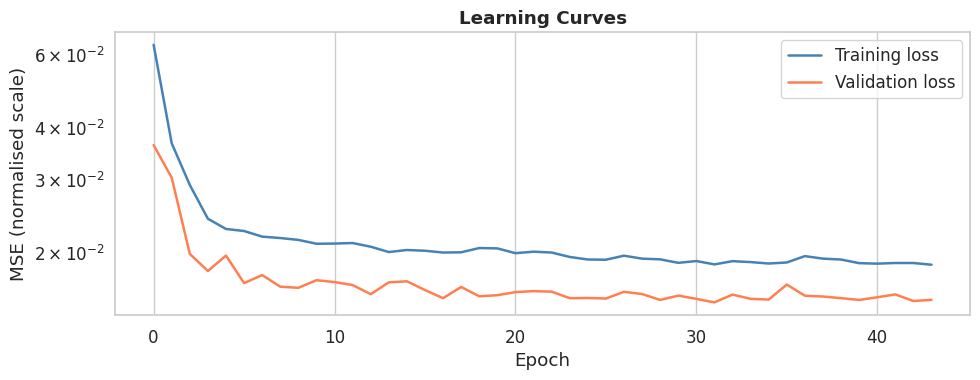

In [13]:
# Load the best model weights and plot learning curves
model.load_state_dict(torch.load(DATA_DIR / 'lstm_model.pt', map_location=DEVICE))
model.eval()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'], label='Training loss',   color='steelblue', lw=1.8)
ax.plot(history['val'],   label='Validation loss', color='coral',     lw=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (normalised scale)')
ax.set_title('Learning Curves', fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(DATA_DIR / 'learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()


A good training run shows both curves decreasing together, with the validation
curve slightly above the training curve. If the gap between them is very large,
the model is overfitting. If neither decreases, the model is underfitting.


---
## Step 10 — Evaluation on the Test Set

We evaluate the trained model on the held-out test set. For context, we also
compute a **persistence baseline**: the simplest possible predictor, which just
says "the output at time t+1 equals the output at time t". Any useful model
must clearly beat this baseline.

Metrics used:
- **R²** (coefficient of determination): 1.0 = perfect, 0.0 = no better than predicting the mean
- **RMSE** (Root Mean Squared Error): average prediction error in the original units (%)


In [14]:
# Collect predictions on the test set
y_pred_list, y_true_list = [], []

with torch.no_grad():
    for xb, yb in dl_test:
        pred = model(xb.to(DEVICE)).cpu().numpy()
        y_pred_list.append(pred)
        y_true_list.append(yb.numpy())

y_pred_norm = np.concatenate(y_pred_list)   # (N_test, 2)  normalised
y_true_norm = np.concatenate(y_true_list)

# Inverse-transform back to physical units (%)
y_pred = scaler_Y.inverse_transform(y_pred_norm)
y_true = scaler_Y.inverse_transform(y_true_norm)

# Persistence baseline: predict y_{t+1} = y_t
y_persist = scaler_Y.inverse_transform(
    Y_all[N_TRAIN + N_VAL + LOOKBACK - 1 : -1]
)[:len(y_true)]

# Print metrics table
print(f"{'Model':<18}  {'R² Iron':>8}  {'RMSE Iron':>10}  {'R² Silica':>10}  {'RMSE Silica':>12}")
print("-" * 64)

for label, y_p in [('Persistence', y_persist), ('LSTM (ours)', y_pred)]:
    r2_fe  = r2_score(y_true[:, 0], y_p[:, 0])
    r2_si  = r2_score(y_true[:, 1], y_p[:, 1])
    rm_fe  = np.sqrt(mean_squared_error(y_true[:, 0], y_p[:, 0]))
    rm_si  = np.sqrt(mean_squared_error(y_true[:, 1], y_p[:, 1]))
    print(f"{label:<18}  {r2_fe:>8.4f}  {rm_fe:>10.4f}  {r2_si:>10.4f}  {rm_si:>12.4f}")


Model                R² Iron   RMSE Iron   R² Silica   RMSE Silica
----------------------------------------------------------------
Persistence           0.4636      0.8327      0.6116        0.7538
LSTM (ours)           0.4924      0.8100      0.6374        0.7283


**Reading the results:**
The persistence baseline already achieves a non-trivial R² (around 0.49 for iron,
0.60 for silica) because process outputs are autocorrelated — the next value tends
to be close to the current value. Our LSTM should clearly outperform this by
learning the influence of past control actions and feed disturbances.


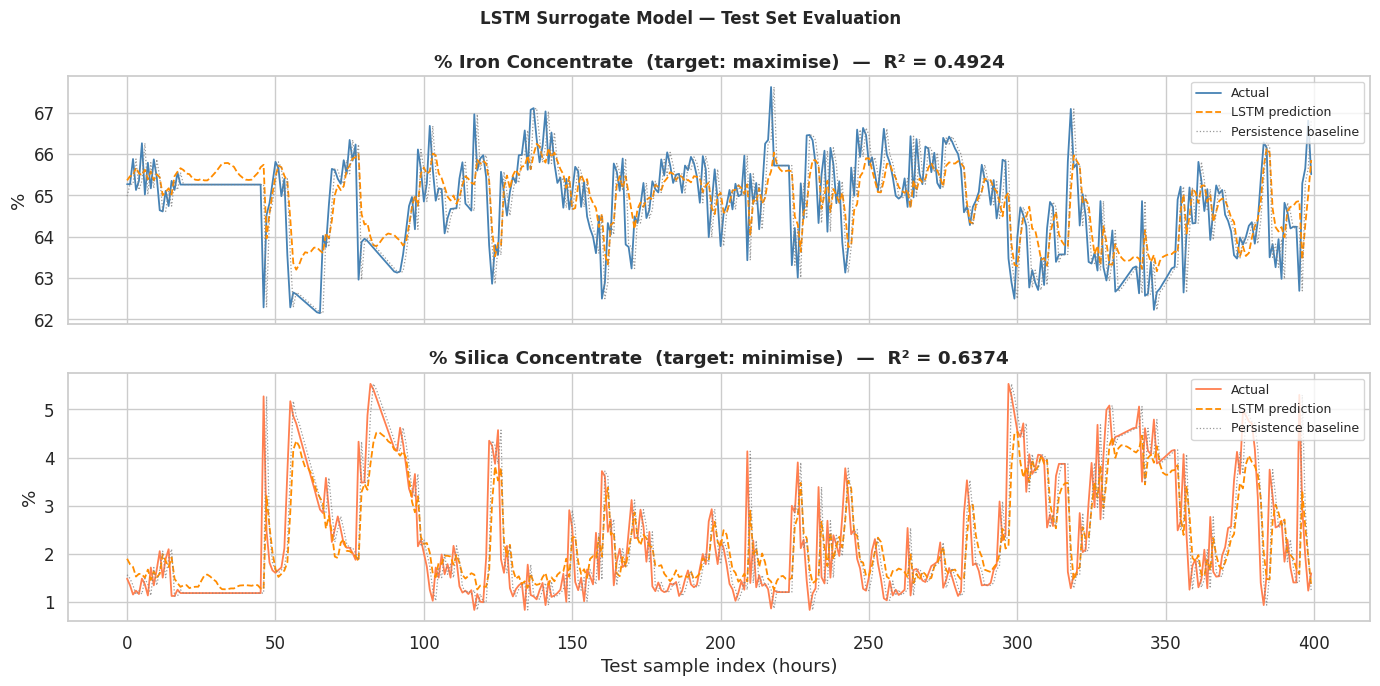

In [15]:
# Plot actual vs predicted for the first 400 test hours
N_SHOW = 400
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
titles = ['% Iron Concentrate  (target: maximise)',
          '% Silica Concentrate  (target: minimise)']

for i, (ax, title) in enumerate(zip(axes, titles)):
    ax.plot(y_true[:N_SHOW, i],  lw=1.3, color='steelblue' if i==0 else 'coral',
            label='Actual')
    ax.plot(y_pred[:N_SHOW, i],  lw=1.3, color='darkorange', ls='--',
            label='LSTM prediction')
    ax.plot(y_persist[:N_SHOW, i], lw=0.9, color='gray', ls=':',
            label='Persistence baseline', alpha=0.8)
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    ax.set_title(f"{title}  —  R² = {r2:.4f}", fontweight='bold')
    ax.set_ylabel('%')
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Test sample index (hours)')
plt.suptitle('LSTM Surrogate Model — Test Set Evaluation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'test_predictions.png', dpi=120, bbox_inches='tight')
plt.show()


The plot shows how closely the LSTM tracks the actual plant output compared to
the naive persistence baseline. Where the LSTM curve follows the actual curve
more closely than the gray dotted line, the model has learned something useful
about the process dynamics.


---
## Step 11 — Save Artifacts for Notebook 2

Notebook 2 needs the trained model, scalers, and column definitions to run the
MPC simulation. We save everything into the `data/` folder.


In [16]:
# Save the two scalers
with open(DATA_DIR / 'scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open(DATA_DIR / 'scaler_Y.pkl', 'wb') as f:
    pickle.dump(scaler_Y, f)

# Save column lists and key hyperparameters
metadata = {
    'ALL_COLS'   : ALL_COLS,
    'FEAT_COLS'  : FEAT_COLS,
    'MV_COLS'    : MV_COLS,
    'DV_COLS'    : DV_COLS,
    'CV_COLS'    : CV_COLS,
    'LOOKBACK'   : LOOKBACK,
    'INPUT_DIM'  : INPUT_DIM,
    'HIDDEN_DIM' : HIDDEN_DIM,
    'NUM_LAYERS' : NUM_LAYERS,
    'DROPOUT'    : DROPOUT,
}
with open(DATA_DIR / 'metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

# Save the initial state window for MPC (last LOOKBACK rows of training data)
init_window = X_all[N_TRAIN - LOOKBACK : N_TRAIN]   # shape (24, 63)
init_y      = scaler_Y.inverse_transform(
    Y_all[N_TRAIN - 1].reshape(1, -1))[0]            # last known output in physical units
np.save(DATA_DIR / 'init_window.npy', init_window)
np.save(DATA_DIR / 'init_y.npy',      init_y)

print("Saved artifacts:")
for p in sorted(DATA_DIR.glob('*')):
    print(f"  {p.name:<30}  {p.stat().st_size / 1024:>7.1f} KB")


Saved artifacts:
  X_all_norm.npy                   1008.4 KB
  Y_raw_phys.npy                     32.1 KB
  best_lstm_surrogate.pt           5532.0 KB
  correlation_heatmap.png           157.7 KB
  cv_timeseries.png                 280.9 KB
  error_histograms.png               61.6 KB
  init_window.npy                     6.0 KB
  init_y.npy                          0.1 KB
  learning_curves.png                49.2 KB
  lstm_model.pt                     938.2 KB
  metadata.pkl                        2.5 KB
  mpc_cost_time.png                  72.3 KB
  mpc_cv_trajectory.png              94.3 KB
  mpc_init_window.npy                 6.0 KB
  mpc_init_y_prev.npy                 0.1 KB
  mpc_mv_airflow.png                 91.8 KB
  mpc_mv_level.png                   87.5 KB
  mpc_vs_openloop.png               136.0 KB
  paradigm_comparison.png           149.2 KB
  predictions_timeseries.png        431.4 KB
  radar_comparison.png              237.1 KB
  scaler_X.pkl                        

**Summary of saved files:**

| File | Contents | Used in |
|------|----------|---------|
| `lstm_model.pt` | Trained LSTM weights | Notebook 2 |
| `scaler_X.pkl` | MinMaxScaler for the 63 input features | Notebook 2 |
| `scaler_Y.pkl` | MinMaxScaler for the 2 outputs | Notebook 2 |
| `metadata.pkl` | Column names, hyperparameters | Notebook 2 |
| `init_window.npy` | Starting state window for the MPC simulation | Notebook 2 |
| `init_y.npy` | Last known output values (physical units) | Notebook 2 |

---

## Summary

In this notebook we:
1. Loaded and cleaned 4,097 hourly observations from the flotation plant
2. Classified the 21 variables into MVs, DVs, and CVs following Unit 7 terminology
3. Added lag and rolling mean features to help the model capture temporal dynamics
4. Trained a 2-layer LSTM to predict iron and silica concentrations one step ahead
5. Evaluated the model against a persistence baseline

The trained LSTM will now serve as the **plant surrogate** inside the MPC loop
in Notebook 2 — replacing the physical equations that would normally be required.

> **Run Notebook 2** to see the closed-loop MPC simulation.
